In [9]:
import sys
print(f"Python version: {sys.version}")

# Install TensorFlow with verbose output to see any errors
!pip install --upgrade pip
!pip install tensorflow --verbose
!C:\Users\User\anaconda3\python.exe -m pip install --upgrade pip
# Restart kernel after installation (add this comment as a reminder)
# You may need to restart your Jupyter kernel after installation

Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Using pip 26.1.1 from C:\Users\User\anaconda3\Lib\site-packages\pip (python 3.13)


In [10]:
!pip show tensorflow

# Now try importing TensorFlow
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

# Verify TensorFlow is working
print(f"TensorFlow version: {tf.__version__}")
print("TensorFlow installed successfully!")

Name: tensorflow
Version: 2.21.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: C:\Users\User\anaconda3\Lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, termcolor, typing_extensions, wrapt
Required-by: 
TensorFlow version: 2.21.0
TensorFlow installed successfully!


In [11]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f'Training data shape: {x_train.shape}')
print(f'Test data shape: {x_test.shape}')
print(f'Number of classes: {len(set(y_train.flatten()))}')

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
Number of classes: 10


In [12]:
def build_model(dropout_rate=0.25, dense_units=128, learning_rate=0.001, l2_reg=0.0):
    """
    Build a CNN model for CIFAR-10 classification.
    Args:
        dropout_rate: Fraction of neurons to drop (regularization)
        dense_units: Number of neurons in the dense layer
        learning_rate: Learning rate for the Adam optimizer
        l2_reg: L2 regularization factor
    """
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), kernel_regularizer=regularizers.l2(l2_reg)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Flatten(),
        layers.Dense(dense_units, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print('Model builder defined.')

Model builder defined.


In [13]:
print('=== Baseline Model ===')
print('Hyperparameters: dropout_rate=0.0, dense_units=512, learning_rate=0.005, l2_reg=0.0')

model_base = build_model(dropout_rate=0.0, dense_units=512, learning_rate=0.005, l2_reg=0.0)

history_base = model_base.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

=== Baseline Model ===
Hyperparameters: dropout_rate=0.0, dense_units=512, learning_rate=0.005, l2_reg=0.0
Epoch 1/10
625/625 - 24s - 38ms/step - accuracy: 0.3676 - loss: 1.7109 - val_accuracy: 0.4644 - val_loss: 1.4516
Epoch 2/10
625/625 - 13s - 21ms/step - accuracy: 0.5025 - loss: 1.3729 - val_accuracy: 0.5322 - val_loss: 1.3132
Epoch 3/10
625/625 - 13s - 21ms/step - accuracy: 0.5454 - loss: 1.2676 - val_accuracy: 0.5630 - val_loss: 1.2248
Epoch 4/10
625/625 - 13s - 20ms/step - accuracy: 0.5779 - loss: 1.1858 - val_accuracy: 0.5607 - val_loss: 1.2423
Epoch 5/10
625/625 - 13s - 20ms/step - accuracy: 0.5961 - loss: 1.1258 - val_accuracy: 0.5846 - val_loss: 1.1914
Epoch 6/10
625/625 - 13s - 21ms/step - accuracy: 0.6187 - loss: 1.0763 - val_accuracy: 0.5630 - val_loss: 1.2586
Epoch 7/10
625/625 - 13s - 21ms/step - accuracy: 0.6360 - loss: 1.0173 - val_accuracy: 0.5894 - val_loss: 1.1989
Epoch 8/10
625/625 - 13s - 21ms/step - accuracy: 0.6564 - loss: 0.9716 - val_accuracy: 0.5831 - val_lo

In [14]:
print('=== Tuned Model ===')
print('Hyperparameters: dropout_rate=0.4, dense_units=256, learning_rate=0.001, l2_reg=0.0001')

model_tuned = build_model(dropout_rate=0.4, dense_units=256, learning_rate=0.001, l2_reg=0.0001)

history_tuned = model_tuned.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

=== Tuned Model ===
Hyperparameters: dropout_rate=0.4, dense_units=256, learning_rate=0.001, l2_reg=0.0001
Epoch 1/10
625/625 - 12s - 18ms/step - accuracy: 0.3893 - loss: 1.6835 - val_accuracy: 0.5098 - val_loss: 1.3802
Epoch 2/10
625/625 - 10s - 15ms/step - accuracy: 0.5393 - loss: 1.3200 - val_accuracy: 0.5719 - val_loss: 1.2436
Epoch 3/10
625/625 - 10s - 15ms/step - accuracy: 0.6064 - loss: 1.1630 - val_accuracy: 0.6110 - val_loss: 1.1465
Epoch 4/10
625/625 - 10s - 15ms/step - accuracy: 0.6466 - loss: 1.0639 - val_accuracy: 0.6539 - val_loss: 1.0497
Epoch 5/10
625/625 - 10s - 15ms/step - accuracy: 0.6762 - loss: 0.9929 - val_accuracy: 0.6781 - val_loss: 0.9898
Epoch 6/10
625/625 - 10s - 15ms/step - accuracy: 0.6970 - loss: 0.9381 - val_accuracy: 0.6853 - val_loss: 0.9641
Epoch 7/10
625/625 - 10s - 15ms/step - accuracy: 0.7166 - loss: 0.8907 - val_accuracy: 0.6959 - val_loss: 0.9564
Epoch 8/10
625/625 - 10s - 15ms/step - accuracy: 0.7335 - loss: 0.8489 - val_accuracy: 0.7128 - val_lo

In [15]:
test_loss_base, test_acc_base = model_base.evaluate(x_test, y_test, verbose=0)
test_loss_tuned, test_acc_tuned = model_tuned.evaluate(x_test, y_test, verbose=0)

print(f'Baseline Model - Test Accuracy: {test_acc_base:.4f}, Test Loss: {test_loss_base:.4f}')
print(f'Tuned Model    - Test Accuracy: {test_acc_tuned:.4f}, Test Loss: {test_loss_tuned:.4f}')

Baseline Model - Test Accuracy: 0.5856, Test Loss: 1.3032
Tuned Model    - Test Accuracy: 0.7003, Test Loss: 0.9687


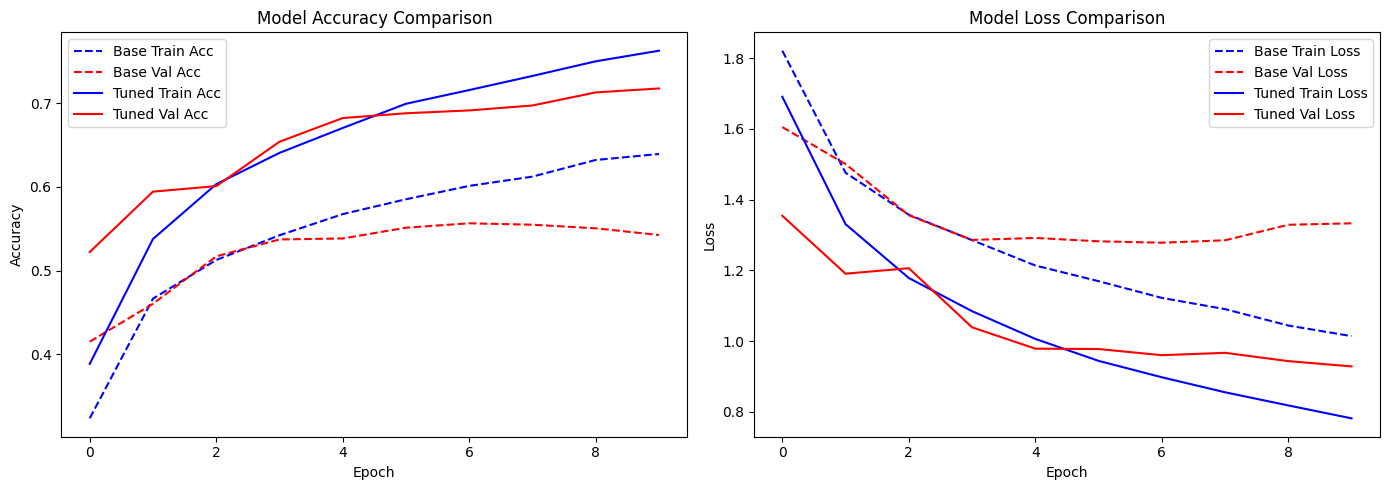

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history_base.history['accuracy'], 'b--', label='Base Train Acc')
ax1.plot(history_base.history['val_accuracy'], 'r--', label='Base Val Acc')
ax1.plot(history_tuned.history['accuracy'], 'b-', label='Tuned Train Acc')
ax1.plot(history_tuned.history['val_accuracy'], 'r-', label='Tuned Val Acc')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss plot
ax2.plot(history_base.history['loss'], 'b--', label='Base Train Loss')
ax2.plot(history_base.history['val_loss'], 'r--', label='Base Val Loss')
ax2.plot(history_tuned.history['loss'], 'b-', label='Tuned Train Loss')
ax2.plot(history_tuned.history['val_loss'], 'r-', label='Tuned Val Loss')
ax2.set_title('Model Loss Comparison')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

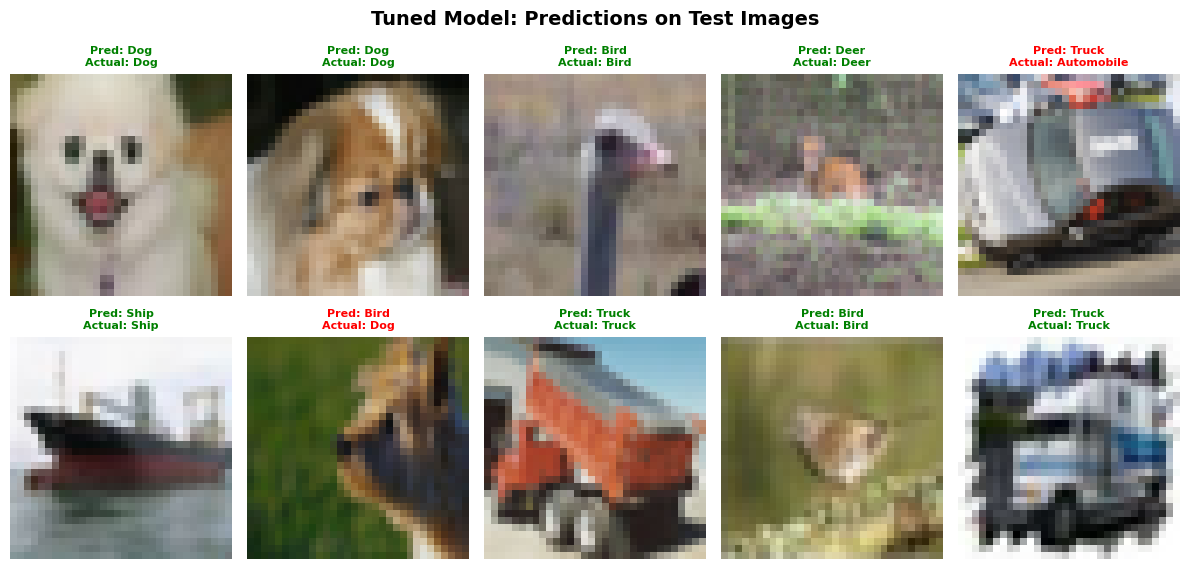

In [16]:
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

y_pred_tuned = np.argmax(model_tuned.predict(x_test, verbose=0), axis=1)
y_true = y_test.flatten()

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    idx = np.random.randint(0, len(x_test))
    ax = axes[i//5, i%5]
    ax.imshow(x_test[idx])
    predicted_class = class_names[y_pred_tuned[idx]]
    actual_class = class_names[y_true[idx]]
    color = 'green' if y_pred_tuned[idx] == y_true[idx] else 'red'
    ax.set_title(f'Pred: {predicted_class}\nActual: {actual_class}', color=color, fontweight='bold', fontsize=8)
    ax.axis('off')
plt.suptitle('Tuned Model: Predictions on Test Images', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()